In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

z_obs = np.load("./co2.npy")
n = z_obs.size

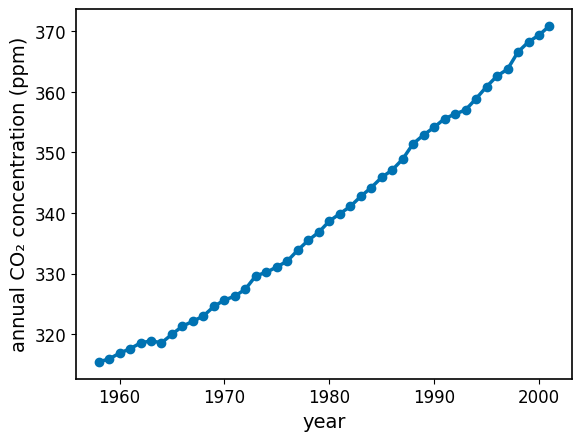

In [2]:
years = np.arange(1958, 2002)

plt.plot(years, z_obs, "o-")
plt.xlabel("year")
plt.ylabel("annual CO₂ concentration (ppm)")
plt.show()

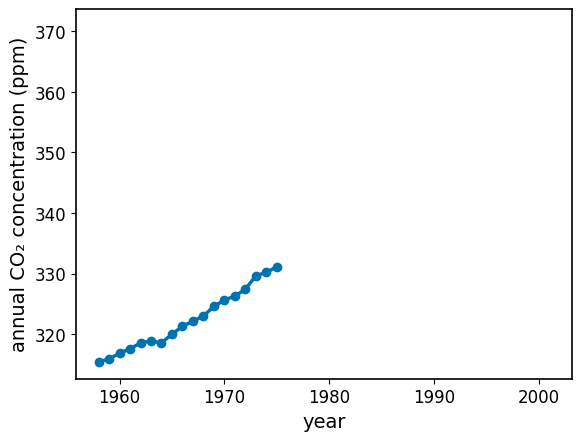

In [3]:
plt.plot(np.arange(1958, 2002), z_obs, "o-", alpha=0)
plt.plot(np.arange(1958, 1976), z_obs[:18], "o-", c="C0")
plt.xlabel("year")
plt.ylabel("annual CO₂ concentration (ppm)")
plt.show()

In [4]:
y = z_obs

# -----------------------------
# Hyperparameter Estimation
# -----------------------------

# Observation variance R:
# Estimate as small fraction of total variance (annual averages are low noise)
R = 0.05 * np.var(y)

# Process variance for 1D random walk:
# Use variance of first differences
diffs = np.diff(y)
Q_1d = np.var(diffs)

# Process variance for 2D model:
# Separate level and slope noise scales
Q_level = 0.1 * np.var(diffs)
Q_slope = 0.01 * np.var(np.diff(diffs)) if len(diffs) > 1 else 1e-4

In [5]:
# Q_1d = 10.0

In [6]:
# ==================================
# 1D RANDOM WALK MODEL
# ==================================

mu_1d = np.zeros(n)
P_1d = np.zeros(n)

pred_mean_1d = np.zeros(n)
pred_var_1d = np.zeros(n)

mu_1d[0] = y[0]
P_1d[0] = np.var(y)

gains = []

for t in range(1, n):

    # ---- Prediction ----
    mu_pred = mu_1d[t-1]
    P_pred = P_1d[t-1] + Q_1d

    pred_mean_1d[t] = mu_pred
    pred_var_1d[t] = P_pred + R   # predictive variance of y_t

    # ---- Update ----
    K = P_pred / (P_pred + R)
    mu_1d[t] = mu_pred + K * (y[t] - mu_pred)
    P_1d[t] = (1 - K) * P_pred

    gains.append(K)

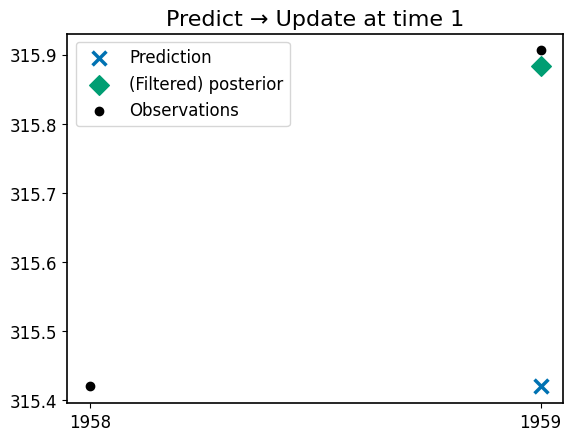

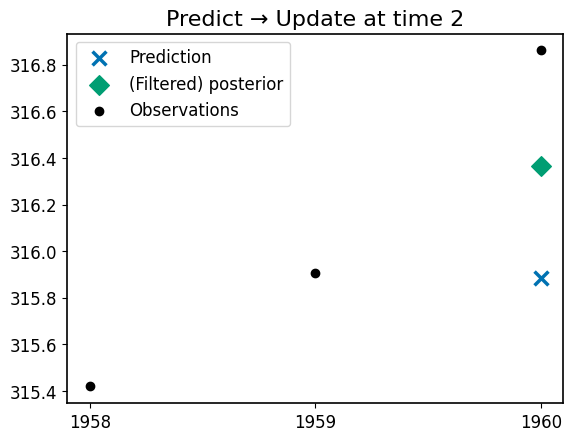

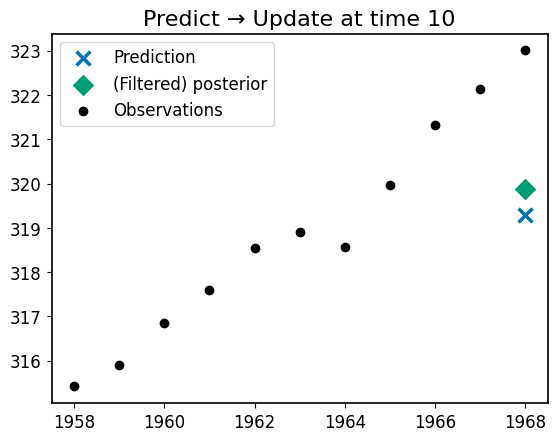

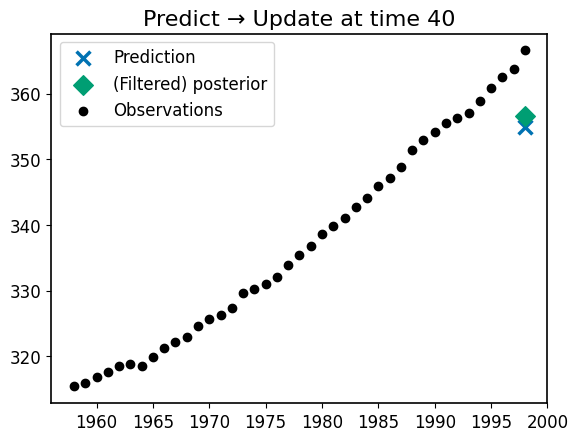

In [7]:
snapshot_times = [1, 2, 10, 40]

for t in snapshot_times:
    plt.figure()

    plt.scatter(years[t], pred_mean_1d[t], marker='x', s=100, label="Prediction")
    # plt.errorbar(years[t], pred_mean_1d[t], yerr=np.sqrt(pred_var_1d[t]), marker="x", capsize=5, label="Prediction")
    plt.scatter(years[t], mu_1d[t], s=100, marker="D", label="(Filtered) posterior")
    # plt.errorbar(years[t], mu_1d[t], yerr=np.sqrt(P_1d[t]), marker='o', capsize=5, label="(Filtered) posterior")

    plt.scatter(years[:t+1], z_obs[:t+1], c="k", label="Observations")

    # plt.scatter(years[t], pred_mean_2d[t], marker='x', s=100, label="2D prediction")
    # plt.scatter(years[t], mu_2d[t, 0], marker='o', s=100, label="2D posterior")

    if t < 5:
        plt.xticks(years[:t+1])
    plt.legend()
    plt.title(f"Predict → Update at time {t}")
    plt.show()

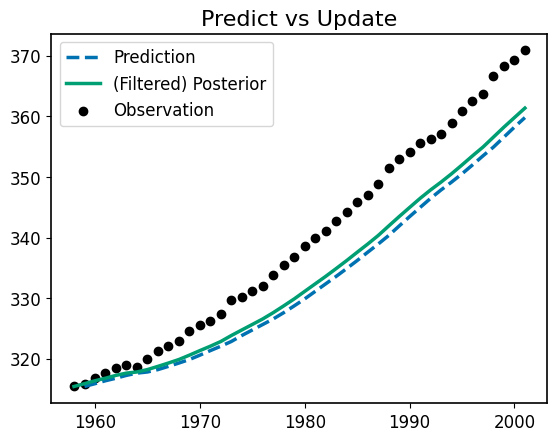

In [8]:
plt.figure()
plt.plot(years[1:], pred_mean_1d[1:], linestyle="--", label="Prediction")
plt.plot(years, mu_1d, label="(Filtered) Posterior")
plt.scatter(years, z_obs, c="k", label="Observation")
plt.legend()
plt.title("Predict vs Update")
plt.show()

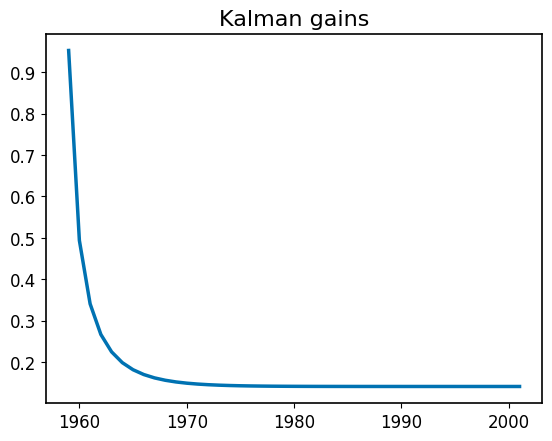

In [9]:
plt.figure()
plt.plot(years[1:], gains)
plt.title("Kalman gains")
plt.show()

In [25]:
# ==================================
# FORECAST FROM YEAR (WITH FULL PLOT)
# ==================================

def forecast_and_plot(year, years, y, mu_filt, P_filt, Q, R):

    # Find index of starting year
    t0 = np.where(years == year)[0][0]

    # ----------------------------
    # Forward forecast (open loop)
    # ----------------------------
    mu_fore = mu_filt[t0]
    P_fore = P_filt[t0]

    future_years = years[t0:]
    state_mean = np.zeros(len(future_years))
    state_var = np.zeros(len(future_years))
    obs_mean = np.zeros(len(future_years))
    obs_var = np.zeros(len(future_years))

    state_mean[0] = mu_fore
    state_var[0] = P_fore
    obs_mean[0] = mu_fore
    obs_var[0] = P_fore + R

    for k in range(1, len(future_years)):

        # Random walk prediction
        mu_fore = mu_fore
        P_fore = P_fore + Q

        state_mean[k] = mu_fore
        state_var[k] = P_fore

        obs_mean[k] = mu_fore
        obs_var[k] = P_fore + R

    # Observed data
    plt.scatter(years[:t0+1], y[:t0+1], c="k", label="Observed")

    # Filtered fit (entire timeline)
    plt.plot(years[:t0+1], mu_filt[:t0+1], label="Filtered posterior")

    # Filter uncertainty (optional)
    filt_lower = mu_filt - 1.96*np.sqrt(P_filt + R)
    filt_upper = mu_filt + 1.96*np.sqrt(P_filt + R)
    plt.fill_between(years[:t0+1], filt_lower[:t0+1], filt_upper[:t0+1], alpha=0.15)

    # Forecast mean
    plt.plot(future_years, obs_mean, label=f"Forecast from {year}")

    # Forecast uncertainty
    lower = obs_mean - 1.96*np.sqrt(obs_var)
    upper = obs_mean + 1.96*np.sqrt(obs_var)
    plt.fill_between(future_years, lower, upper, alpha=0.3)

    # Vertical line marking forecast start
    plt.axvline(year, linestyle="--", color="k")

    plt.title(f"Forecast Starting at {year}")
    plt.legend()
    plt.show()

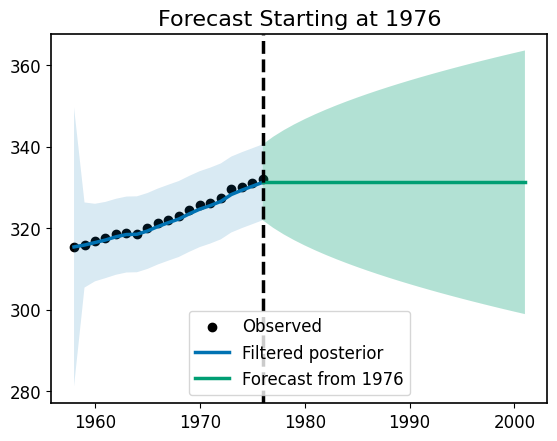

In [26]:
forecast_and_plot(
    1976,
    years,
    y,
    mu_1d,
    P_1d,
    Q_1d,
    R
)

In [11]:
# ==================================
# 2D LOCAL LINEAR TREND MODEL
# ==================================

mu_2d = np.zeros((n, 2))
P_2d = np.zeros((n, 2, 2))

pred_mean_2d = np.zeros(n)
pred_var_2d = np.zeros(n)

mu_2d[0, 0] = y[0]
mu_2d[0, 1] = diffs[0] if len(diffs) > 0 else 0.0
P_2d[0] = np.eye(2) * np.var(y)

F = np.array([[1, 1],
              [0, 1]])

H = np.array([[1, 0]])

Q = np.array([[Q_level, 0],
              [0, Q_slope]])

for t in range(1, n):

    # ---- Prediction ----
    mu_pred = F @ mu_2d[t-1]
    P_pred = F @ P_2d[t-1] @ F.T + Q

    pred_mean_2d[t] = (H @ mu_pred)[0]
    pred_var_2d[t] = (H @ P_pred @ H.T)[0, 0] + R

    # ---- Update ----
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    innovation = y[t] - (H @ mu_pred)
    mu_2d[t] = mu_pred + (K.flatten() * innovation)
    P_2d[t] = (np.eye(2) - K @ H) @ P_pred

In [12]:
K

array([[0.17998533],
       [0.01675116]])

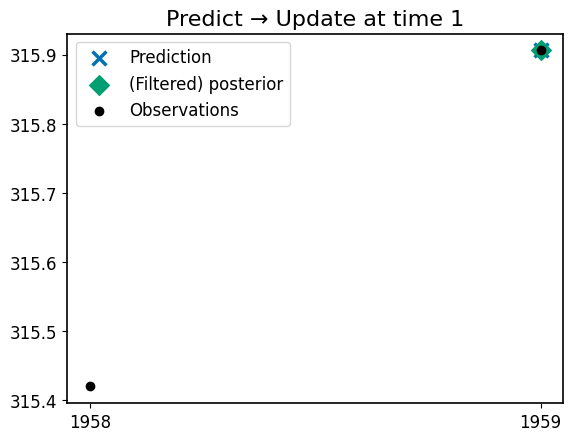

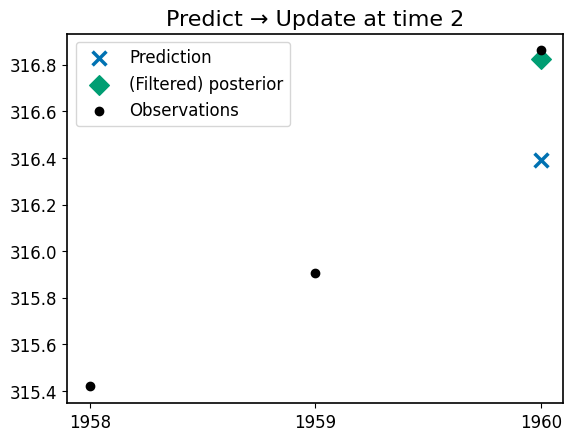

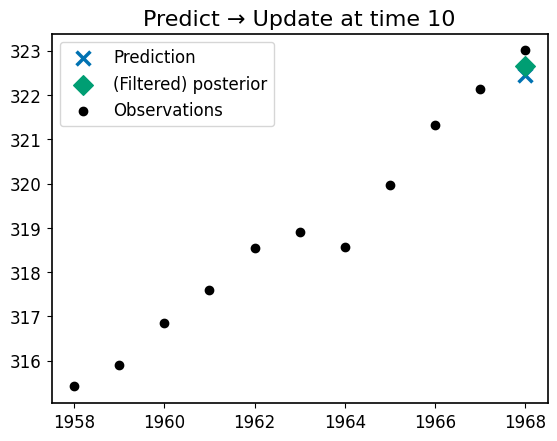

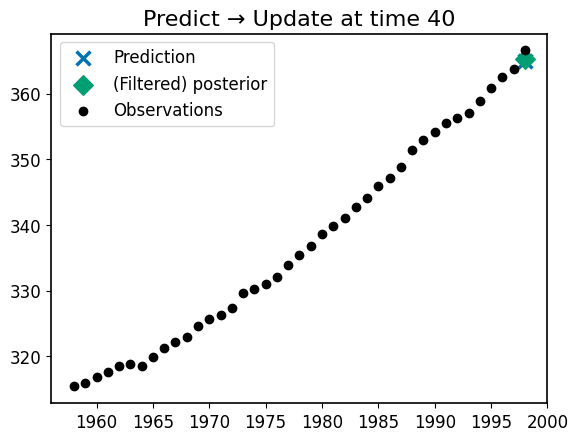

In [13]:
snapshot_times = [1, 2, 10, 40]

for t in snapshot_times:
    plt.figure()

    plt.scatter(years[t], pred_mean_2d[t], marker='x', s=100, label="Prediction")
    # plt.errorbar(years[t], pred_mean_1d[t], yerr=np.sqrt(pred_var_1d[t]), marker="x", capsize=5, label="Prediction")
    plt.scatter(years[t], mu_2d[t, 0], s=100, marker="D", label="(Filtered) posterior")
    # plt.errorbar(years[t], mu_1d[t], yerr=np.sqrt(P_1d[t]), marker='o', capsize=5, label="(Filtered) posterior")

    plt.scatter(years[:t+1], z_obs[:t+1], c="k", label="Observations")

    # plt.scatter(years[t], pred_mean_2d[t], marker='x', s=100, label="2D prediction")
    # plt.scatter(years[t], mu_2d[t, 0], marker='o', s=100, label="2D posterior")

    if t < 5:
        plt.xticks(years[:t+1])
    plt.legend()
    plt.title(f"Predict → Update at time {t}")
    plt.show()

In [14]:
# ==================================
# LONG-HORIZON FORECAST (2D MODEL)
# ==================================

def forecast_2d_from_year(year, years, mu_filt, P_filt, F, H, Q, R):

    # Find index of starting year
    t0 = np.where(years == year)[0][0]

    # Initialize from filtered posterior at t0
    mu_fore = mu_filt[t0].copy()
    P_fore = P_filt[t0].copy()

    future_years = years[t0:]

    state_mean = np.zeros((len(future_years), 2))
    state_var = np.zeros((len(future_years), 2, 2))

    obs_mean = np.zeros(len(future_years))
    obs_var = np.zeros(len(future_years))

    # Store initial point
    state_mean[0] = mu_fore
    state_var[0] = P_fore

    obs_mean[0] = (H @ mu_fore)[0]
    obs_var[0] = (H @ P_fore @ H.T)[0, 0] + R

    # Roll forward without updates
    for k in range(1, len(future_years)):

        # Prediction step only
        mu_fore = F @ mu_fore
        P_fore = F @ P_fore @ F.T + Q

        state_mean[k] = mu_fore
        state_var[k] = P_fore

        obs_mean[k] = (H @ mu_fore)[0]
        obs_var[k] = (H @ P_fore @ H.T)[0, 0] + R

    return future_years, state_mean, state_var, obs_mean, obs_var

In [15]:
future_years, state_mean, state_var, obs_mean, obs_var = \
    forecast_2d_from_year(
        1976,
        years,
        mu_2d,
        P_2d,
        F,
        H,
        Q,
        R
    )

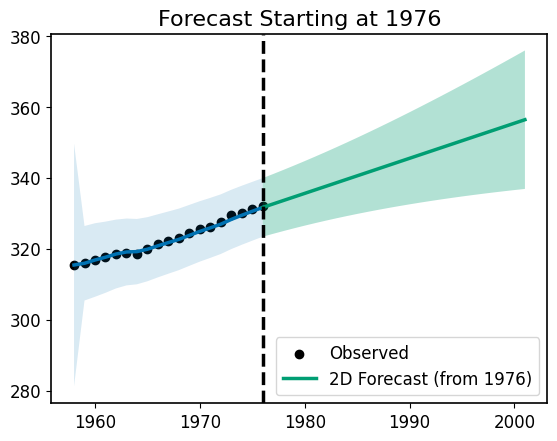

In [33]:
t0 = np.where(years == 1976)[0][0]

# Observed data
plt.scatter(years[:t0+1], y[:t0+1], c="k", label="Observed")

plt.plot(years[:t0+1], mu_2d[:t0+1, 0])
plt.fill_between(
    years[:t0+1],
    mu_2d[:t0+1, 0] - 1.96 * np.sqrt(P_2d[:t0+1, 0, 0] + R),
    mu_2d[:t0+1, 0] + 1.96 * np.sqrt(P_2d[:t0+1, 0, 0] + R),
    alpha=0.15,
)

# Forecast mean
plt.plot(future_years, obs_mean, label="2D Forecast (from 1976)")

# 95% interval
lower = obs_mean - 1.96*np.sqrt(obs_var)
upper = obs_mean + 1.96*np.sqrt(obs_var)
plt.fill_between(future_years, lower, upper, alpha=0.3)

plt.axvline(1976, linestyle="--", color="k")

plt.title("Forecast Starting at 1976")
plt.legend()
plt.show()